# DQN 버전

0단계: (필수) 인터넷 설정
노트북 오른쪽 메뉴의 **[Settings]**에서 **'Internet'**이 **'On'**으로 켜져 있는지 확인하세요.

!pip install을 위해 **반드시 'On'**이 되어야 합니다. (업로드한 파일에는 isInternetEnabled: true로 되어있어 이미 켜진 것 같습니다.

In [1]:
from learntools.core import binder
binder.bind(globals())
from learntools.game_ai.ex4 import *

In [3]:
# Lines below will give you solution code
#q_1.solution()

# [셀1] Deep Learning (DQN, Double DQN, Dueling DQN)

In [17]:
# ---
# 6번 스텝: Deep Learning (DQN, Double DQN, Dueling DQN)
# 
# [수정 2] sample_action 함수에서 obs_tensor를 (1, 6, 7) -> (1, 1, 6, 7)로
#         unsqueeze(0)를 추가하여 CNN 입력 shape을 (B, C, H, W)로 수정했습니다.
# [수정 1] ReplayBuffer의 sample 함수 버그를 수정했습니다.
# ---

# --- 1. 라이브러리 임포트 ---
# (gymnasium이 없으면 설치합니다)
try:
    import gymnasium as gym # gymnasium (최신 gym) 임포트
except ImportError:
    print("gymnasium 설치 중...")
    !pip install gymnasium # gymnasium이 없으면 설치
    import gymnasium as gym

import collections                     # 리플레이 버퍼를 위한 deque 임포트
import random                          # 엡실론 그리디, 버퍼 샘플링용
import numpy as np                     # 보드 상태(State) 처리를 위함
import torch                           # PyTorch (신경망 구현)
import torch.nn as nn                  # PyTorch 신경망 모듈
import torch.optim as optim            # 옵티마이저 (Adam 등)
import torch.nn.functional as F        # 활성화 함수 (ReLU 등)
from kaggle_environments import make   # ConnectX 환경 생성용
from gym import spaces                 # 환경의 행동/관찰 공간 정의용
import time                            # 학습 시간 측정용
import pandas as pd                    # 결과 그래프용
import matplotlib.pyplot as plt        # 결과 그래프용
# stable-baselines3 임포트 제거 (PPO를 사용하지 않음)

print("라이브러리 임포트 완료.")

# --- 2. ConnectX 환경 클래스 (4-exercise... 파일에서 가져옴) ---
# (참고: PyTorch 호환성을 위해 최신 gymnasium.Env 규격으로 수정)
class ConnectFourGym(gym.Env):
    # 초기화 함수: 상대 에이전트(agent2)를 'random'으로 설정
    def __init__(self, agent2="random"):
        ks_env = make("connectx", debug=True) # 캐글 ConnectX 환경 생성
        self.env = ks_env.train([None, agent2]) # 학습용 환경 설정 (P1=우리 에이전트, P2=random)
        self.rows = ks_env.configuration.rows # 6
        self.columns = ks_env.configuration.columns # 7
        self.config = ks_env.configuration # 나중에 sample_action에서 사용하기 위해 저장
        
        # 행동 공간: 7개 열 (0~6) 중 하나를 선택 (이산 공간)
        self.action_space = spaces.Discrete(self.columns)
        # 관찰 공간: (1, 6, 7) 형태의 2D 보드 (0=빈칸, 1=내돌, 2=상대돌)
        # (채널, 높이, 너비) 순서 (CNN 입력에 적합)
        self.observation_space = spaces.Box(low=0, high=2, 
                                            shape=(1, self.rows, self.columns), dtype=int)
        self.reward_range = (-10, 1) # 보상 범위
        self.spec = None
        self.metadata = None

    # 환경 리셋 함수
    def reset(self, seed=None, options=None):
        self.obs = self.env.reset() # 캐글 환경 리셋
        # (1, 6, 7) numpy 배열과 빈 info 딕셔너리 반환 (gym 최신 규격)
        return np.array(self.obs['board']).reshape(1, self.rows, self.columns), {}

    # 보상 재설계 함수 (Reward Shaping)
    def change_reward(self, old_reward, done):
        if old_reward == 1: # 승리
            return 1.0
        elif done: # 패배 (상대가 이김)
            return -1.0
        else: # 진행 중
            return 1.0 / (self.rows * self.columns) # (1/42), 작은 긍정적 보상

    # 행동 실행 함수
    def step(self, action):
        # 유효한 수인지 확인 (해당 열의 맨 위가 0(빈칸)인지)
        is_valid = (self.obs['board'][int(action)] == 0)
        if is_valid: # 유효한 수
            self.obs, old_reward, done, _ = self.env.step(int(action)) # 행동 실행
            reward = self.change_reward(old_reward, done) # 보상 재설계
        else: # 유효하지 않은 수 (꽉 찬 열 선택 등)
            reward, done, _ = -10.0, True, {} # 큰 페널티(-10) 부여 및 게임 즉시 종료
        
        # (obs, reward, terminated, truncated, info) 5개 값 반환 (gym 최신 규격)
        return np.array(self.obs['board']).reshape(1, self.rows, self.columns), reward, done, False, {}

print("ConnectFourGym 환경 클래스 정의 완료.")

# --- 3. 하이퍼파라미터 (ex011... 파일 참고) ---
learning_rate = 0.0005  # 학습률
gamma = 0.98            # 할인 인자 (미래 보상 감가)
buffer_limit = 50000    # 리플레이 버퍼 크기
batch_size = 32         # 한 번에 학습할 샘플 개수

# --- 4. 리플레이 버퍼 (ex011... 파일과 동일) ---
class ReplayBuffer():
    def __init__(self):
        # 'deque'는 양쪽 끝에서 추가/삭제가 빠른 자료구조
        self.buffer = collections.deque(maxlen=buffer_limit)

    def put(self, transition):
        # 버퍼에 (S, A, R, S', Done) 튜플 저장
        self.buffer.append(transition)

    def sample(self, n):
        # 버퍼에서 'n'개 만큼 무작위로 샘플링
        mini_batch = random.sample(self.buffer, n)
        # 샘플들을 S, A, R, S', Done 리스트로 분리
        s_lst, a_lst, r_lst, s_prime_lst, done_mask_lst = [], [], [], [], []
        for transition in mini_batch:
            s, a, r, s_prime, done_mask = transition
            s_lst.append(s)
            a_lst.append([a])
            r_lst.append([r])
            s_prime_lst.append(s_prime)
            done_mask_lst.append([done_mask])
        
        # [버그 수정 1] s_lst는 (1,6,7) 배열 32개가 담긴 리스트입니다.
        # np.array(s_lst)는 (32, 1, 6, 7) 형상의 4D 텐서를 올바르게 생성합니다.
        return torch.tensor(np.array(s_lst), dtype=torch.float), torch.tensor(a_lst), \
               torch.tensor(r_lst), torch.tensor(np.array(s_prime_lst), dtype=torch.float), \
               torch.tensor(done_mask_lst)
    
    def size(self):
        # 현재 버퍼에 저장된 샘플 개수 반환
        return len(self.buffer)
print("ReplayBuffer 클래스 정의 완료. (버그 수정됨)")

# --- 5. 신경망 모델 (DQN / Dueling DQN) ---

# [실험 6.1, 6.2] DQN, Double DQN에서 사용할 기본 CNN Q-Network
class Qnet_ConnectX(nn.Module):
    def __init__(self, action_space=7):
        super(Qnet_ConnectX, self).__init__()
        # 6.4 CNN Feature: 2D 보드 패턴을 읽기 위한 CNN
        self.cnn = nn.Sequential(
            # 입력: (Batch, 1, 6, 7)
            nn.Conv2d(1, 32, kernel_size=3, stride=1), # (Batch, 32, 4, 5)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=1), # (Batch, 64, 2, 3)
            nn.ReLU(),
            nn.Flatten() # 1차원 벡터로 펼치기 (Batch, 64 * 2 * 3 = 384)
        )
        # 384개의 특징을 받아 7개의 Q값(각 열의 점수)으로 출력
        self.fc_q = nn.Linear(384, action_space) # Q(s, a) 출력

    def forward(self, x):
        x = self.cnn(x)  # CNN으로 특징 추출
        q = self.fc_q(x) # Q-value 계산
        return q

    # Epsilon-Greedy 방식으로 행동 샘플링 (유효한 수만 고려)
    def sample_action(self, obs, epsilon, config):
        # --- [버그 수정 2] ---
        # obs (1, 6, 7) -> (1, 1, 6, 7)로 배치 차원 추가
        # .unsqueeze(0)을 추가하여 (B, C, H, W) shape을 맞춥니다.
        obs_tensor = torch.from_numpy(obs).float().unsqueeze(0) 
        
        out = self.forward(obs_tensor) # 모델 통과 -> Q-values (1, 7)
        
        coin = random.random() # 0~1 사이 난수
        if coin < epsilon: # 엡실론 확률로: 탐험 (무작위 행동)
            # 유효한 수(맨 위가 0인 열) 중에서만 랜덤 선택
            valid_moves = [c for c in range(config.columns) if obs[0][0][c] == 0]
            if not valid_moves: return 0 # 둘 곳이 없으면 0 반환
            return random.choice(valid_moves)
        else: # 1-엡실론 확률로: 활용 (Q값이 가장 높은 행동)
            q_values = out[0] # (7,) 텐서
            valid_moves = [c for c in range(config.columns) if obs[0][0][c] == 0]
            
            # 유효하지 않은 수는 Q값을 -inf로 마스킹
            masked_q_values = torch.full_like(q_values, -float('inf'))
            for move in valid_moves:
                masked_q_values[move] = q_values[move]
                
            return masked_q_values.argmax().item() # Q값이 가장 높은 유효한 수 반환
print("Qnet_ConnectX (DQN 모델) 클래스 정의 완료.")

# [실험 6.3] Dueling DQN에서 사용할 Dueling CNN Q-Network
class DuelingQnet_ConnectX(nn.Module):
    def __init__(self, action_space=7):
        super(DuelingQnet_ConnectX, self).__init__()
        # 6.4 CNN Feature: 특징 추출용 CNN은 동일
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1), 
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten() # (Batch, 384)
        )
        
        # 1. Value Stream (상태의 가치 V(s))
        self.fc_value = nn.Linear(384, 128)
        self.value = nn.Linear(128, 1) # V(s) - 스칼라 값 1개 출력

        # 2. Advantage Stream (행동의 우위 A(s, a))
        self.fc_adv = nn.Linear(384, 128)
        self.adv = nn.Linear(128, action_space) # A(s, a) - 7개 값 출력

    def forward(self, x):
        x = self.cnn(x) # CNN 통과
        
        v = F.relu(self.fc_value(x)) # 가치 스트림
        a = F.relu(self.fc_adv(x)) # 행동 스트림
        
        v = self.value(v) # V(s)
        a = self.adv(a)   # A(s, a)
        
        # Dueling Network 결합 공식: Q = V + (A - mean(A))
        a_avg = torch.mean(a, dim=1, keepdim=True) # A(s, a)의 평균
        q = v + a - a_avg
        return q

    # sample_action은 Qnet_ConnectX와 동일
    def sample_action(self, obs, epsilon, config):
        # --- [버그 수정 2] ---
        # obs (1, 6, 7) -> (1, 1, 6, 7)로 배치 차원 추가
        obs_tensor = torch.from_numpy(obs).float().unsqueeze(0) 
        
        out = self.forward(obs_tensor) 
        coin = random.random()
        if coin < epsilon:
            valid_moves = [c for c in range(config.columns) if obs[0][0][c] == 0]
            if not valid_moves: return 0
            return random.choice(valid_moves)
        else:
            q_values = out[0]
            valid_moves = [c for c in range(config.columns) if obs[0][0][c] == 0]
            masked_q_values = torch.full_like(q_values, -float('inf'))
            for move in valid_moves:
                masked_q_values[move] = q_values[move]
            return masked_q_values.argmax().item()
print("DuelingQnet_ConnectX (Dueling 모델) 클래스 정의 완료.")

# --- 6. 학습 함수 (알고리즘별로 분리) ---

# [실험 6.1] DQN을 위한 학습 함수 (ex011... 로직 기반)
def train_dqn(q, q_target, memory, optimizer):
    for i in range(10): # ex011... 예제처럼 10번 반복 학습
        # 리플레이 버퍼에서 미니배치 샘플링
        s,a,r,s_prime,done_mask = memory.sample(batch_size)
        
        # 1. 현재 Q값 계산: q(s, a)
        q_out = q(s) # (Batch, 7)
        q_a = q_out.gather(1,a) # (Batch, 1) - 실제 행동(a)의 Q값

        # 2. 타겟 Q값 계산: r + gamma * max(q_target(s'))
        with torch.no_grad(): # 타겟 계산 시에는 그래디언트 전파 X
            q_prime = q_target(s_prime) # 타겟 네트워크가 다음 상태(s')의 Q값 계산 (Batch, 7)
            
            # [수정됨] ConnectX의 유효한 수만 고려
            valid_moves_mask = (s_prime[:, 0, 0, :] == 0) # (Batch, 7) - s'의 맨 윗줄이 0(빈칸)인지
            q_prime[~valid_moves_mask] = -float('inf') # 유효하지 않으면 -inf
            
            # DQN 타겟: 타겟 네트워크의 Q값 중 최대값
            max_q_prime = q_prime.max(1)[0].unsqueeze(1) # (Batch, 1)
        
        # 타겟 Q값 (TD Target)
        target = r + gamma * max_q_prime * done_mask
        
        # 3. 손실(Loss) 계산 및 역전파
        loss = F.mse_loss(q_a, target) # (현재 Q값 - 타겟 Q값)의 제곱 오차
        optimizer.zero_grad() # 그래디언트 초기화
        loss.backward() # 역전파
        optimizer.step() # 파라미터 업데이트
print("train_dqn (학습 함수 1) 정의 완료.")

# [실험 6.2, 6.3] Double DQN (Dueling)을 위한 학습 함수 (ex011... 로직 기반)
def train_double_dqn(q, q_target, memory, optimizer):
    for i in range(10):
        s,a,r,s_prime,done_mask = memory.sample(batch_size)
        
        # 1. 현재 Q값 계산: q(s, a) (DQN과 동일)
        q_out = q(s)
        q_a = q_out.gather(1,a)

        # 2. 타겟 Q값 계산 (Double DQN 방식)
        with torch.no_grad():
            # 행동 선택: *메인* 네트워크 (q)가 다음 상태(s')에서 Q값이 가장 높은 행동(a')을 선택
            q_prime_main = q(s_prime) 
            valid_moves_mask = (s_prime[:, 0, 0, :] == 0)
            q_prime_main[~valid_moves_mask] = -float('inf')
            argmax_Q = q_prime_main.max(1)[1].unsqueeze(1) # (Batch, 1) - 행동 인덱스
            
            # 가치 평가: *타겟* 네트워크 (q_target)가 그 행동(a')의 Q값을 계산
            max_q_prime = q_target(s_prime).gather(1, argmax_Q) # (Batch, 1)
        
        # 타겟 Q값 (TD Target)
        target = r + gamma * max_q_prime * done_mask
        
        # 3. 손실 계산 및 역전파 (DQN과 동일)
        loss = F.mse_loss(q_a, target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
print("train_double_dqn (학습 함수 2) 정의 완료.")

# --- 7. 실험 실행 함수 (현지님의 계획을 위한 제어 센터) ---
# (이 함수가 ex011...의 'main' 역할을 대체)
def run_experiment(algorithm_type="DQN", n_episodes=10000):
    print(f"\n=== {algorithm_type} 학습 시작 ===")
    start_time = time.time() # 시작 시간
    
    # 환경 생성 (상대는 'random')
    env = ConnectFourGym(agent2="random")
    config = env.config # config 객체 (행/열 정보)

    # --- 현지님의 계획에 따라 모델과 학습 함수를 "변형" (선택) ---
    if algorithm_type == "Dueling_DQN":
        # 6.3 Dueling DQN: Dueling 모델 + Double 학습
        q = DuelingQnet_ConnectX(action_space=env.action_space.n)
        q_target = DuelingQnet_ConnectX(action_space=env.action_space.n)
        train_fn = train_double_dqn
    elif algorithm_type == "Double_DQN":
        # 6.2 Double DQN: 기본 모델 + Double 학습
        q = Qnet_ConnectX(action_space=env.action_space.n)
        q_target = Qnet_ConnectX(action_space=env.action_space.n)
        train_fn = train_double_dqn
    else: # "DQN"
        # 6.1 DQN: 기본 모델 + 기본 학습
        q = Qnet_ConnectX(action_space=env.action_space.n)
        q_target = Qnet_ConnectX(action_space=env.action_space.n)
        train_fn = train_dqn
    # --- 여기까지가 알고리즘별 "변형" 지점입니다 ---

    q_target.load_state_dict(q.state_dict()) # 타겟 네트워크 가중치 초기화
    memory = ReplayBuffer() # 리플레이 버퍼 생성
    optimizer = optim.Adam(q.parameters(), lr=learning_rate) # 옵티마이저 생성

    print_interval = 20 # 20 에피소드마다 로그 출력
    score = 0.0 # 20 에피소드의 누적 점수
    scores_history = [] # 그래프를 그리기 위한 모든 에피소드 점수 기록

    for n_epi in range(n_episodes):
        # 엡실론 값 조절 (학습 초반엔 10% 탐험, 후반엔 1%로 수렴)
        epsilon = max(0.01, 0.1 - 0.01*(n_epi/200))
        s, _ = env.reset() # 환경 리셋, (1, 6, 7) 상태 받음
        done = False
        episode_score = 0.0 # 이번 에피소드의 점수

        while not done:
            # config 객체를 sample_action에 전달 (유효한 수 탐색용)
            a = q.sample_action(s, epsilon, config) 
            # 행동 실행 -> (다음상태, 보상, 종료여부, ...)
            s_prime, r, done, truncated, _ = env.step(a)
            
            done_mask = 0.0 if (done or truncated) else 1.0 # 게임 종료 시 0, 아니면 1
            # 리플레이 버퍼에 (S, A, R, S', Done) 저장
            memory.put((s, a, r, s_prime, done_mask)) 
            s = s_prime # 상태 업데이트
            
            score += r
            episode_score += r
            if done or truncated:
                break
        
        scores_history.append(episode_score) # 에피소드 점수 기록

        # 버퍼가 2000개 이상 쌓이면 학습 시작
        if memory.size() > 2000:
            train_fn(q, q_target, memory, optimizer) # 선택된 학습 함수로 10회 학습

        # 20 에피소드마다 로그 출력 및 타겟 네트워크 업데이트
        if n_epi % print_interval == 0 and n_epi != 0:
            q_target.load_state_dict(q.state_dict()) # 메인 네트워크 가중치를 타겟으로 복사
            print(f"n_episode: {n_epi}, avg_score: {score/print_interval:.2f}, n_buffer: {memory.size()}, eps: {epsilon*100:.1f}%")
            score = 0.0 # 누적 점수 리셋

    env.close() # 환경 종료
    total_time = time.time() - start_time
    print(f"=== {algorithm_type} 학습 종료 (총 {total_time:.2f}초) ===")
    return q, scores_history # 학습된 모델과 점수 기록 반환
print("run_experiment (실험 제어 센터) 정의 완료.")

# --- 8. (DQN 모델) 에이전트 제출 함수 ---
# (Kaggle 대회 제출용 에이전트 함수)

# 전역 변수로 학습된 모델을 저장할 공간
trained_model_dict = {}

# 캐글 환경(obs, config)을 입력받는 에이전트 함수
def dqn_agent(obs, config):
    # (주의!) trained_model_dict에 "DQN", "Double_DQN" 등 원하는 모델이
    # run_experiment()를 통해 미리 저장되어 있어야 합니다.
    
    # 보고서 제출용으로 실험한 모델 중 가장 좋은 모델을 선택하세요.
    # (여기서는 "DQN"을 기본으로 하지만, "Double_DQN" 등으로 바꿀 수 있습니다)
    model = trained_model_dict.get("DQN") 
    
    if model is None: # 만약 학습된 모델이 없으면 랜덤
        # print("학습된 모델을 찾을 수 없어 랜덤 에이전트를 사용합니다.")
        return random.choice([c for c in range(config.columns) if obs.board[c] == 0])

    # obs (1D list) -> (1, 6, 7) numpy 배열로 변환
    s = np.array(obs['board']).reshape(1, config.rows, config.columns)
    
    # config 객체 전달 (sample_action이 유효한 수를 확인하기 위해 필요)
    agent_config = config
    
    # sample_action에 config 전달
    # epsilon=0.0 (활용)으로 최적의 수 계산
    action = model.sample_action(s, epsilon=0.0, config=agent_config)
    
    return int(action)
print("dqn_agent (제출용 에이전트 함수) 정의 완료.")
print("\n--- 모든 정의가 완료되었습니다. 다음 셀에서 학습을 시작하세요. ---")

라이브러리 임포트 완료.
ConnectFourGym 환경 클래스 정의 완료.
ReplayBuffer 클래스 정의 완료. (버그 수정됨)
Qnet_ConnectX (DQN 모델) 클래스 정의 완료.
DuelingQnet_ConnectX (Dueling 모델) 클래스 정의 완료.
train_dqn (학습 함수 1) 정의 완료.
train_double_dqn (학습 함수 2) 정의 완료.
run_experiment (실험 제어 센터) 정의 완료.
dqn_agent (제출용 에이전트 함수) 정의 완료.

--- 모든 정의가 완료되었습니다. 다음 셀에서 학습을 시작하세요. ---


# 실험 6.1: DQN 학습 시작 (셀 2)

In [18]:
# [셀 1]의 모든 코드가 실행된 후, 이 셀을 실행하세요.

print("--- 6.1 DQN 실험 시작 ---")

# n_episodes는 1000 (테스트용)
# (나중에 보고서용으로는 10000 이상으로 늘려서 실행하세요)
model_dqn, scores_dqn = run_experiment("DQN", n_episodes=1000) 

# dqn_agent가 이 모델을 사용하도록 전역 변수에 저장
# (8. 최종 에이전트 제출 및 테스트용)
trained_model_dict["DQN"] = model_dqn 
print("--- DQN 모델 저장 완료 ---")

--- 6.1 DQN 실험 시작 ---

=== DQN 학습 시작 ===
n_episode: 20, avg_score: 0.42, n_buffer: 161, eps: 9.9%
n_episode: 40, avg_score: 0.26, n_buffer: 319, eps: 9.8%
n_episode: 60, avg_score: 0.35, n_buffer: 465, eps: 9.7%
n_episode: 80, avg_score: 0.46, n_buffer: 618, eps: 9.6%
n_episode: 100, avg_score: 0.66, n_buffer: 769, eps: 9.5%
n_episode: 120, avg_score: 0.64, n_buffer: 908, eps: 9.4%
n_episode: 140, avg_score: 0.55, n_buffer: 1053, eps: 9.3%
n_episode: 160, avg_score: 0.56, n_buffer: 1208, eps: 9.2%
n_episode: 180, avg_score: 0.56, n_buffer: 1366, eps: 9.1%
n_episode: 200, avg_score: 0.55, n_buffer: 1516, eps: 9.0%
n_episode: 220, avg_score: 0.65, n_buffer: 1665, eps: 8.9%
n_episode: 240, avg_score: 0.65, n_buffer: 1809, eps: 8.8%
n_episode: 260, avg_score: 0.92, n_buffer: 1930, eps: 8.7%
n_episode: 280, avg_score: 0.84, n_buffer: 2065, eps: 8.6%
n_episode: 300, avg_score: 0.86, n_buffer: 2217, eps: 8.5%
n_episode: 320, avg_score: 0.87, n_buffer: 2377, eps: 8.4%
n_episode: 340, avg_score

# [셀 3] Double DQN 학습 시작

In [19]:
# [셀 2]의 학습이 완료된 후, 이 셀을 실행하세요.

print("--- 6.2 Double DQN 실험 시작 ---")

# n_episodes는 1000 (테스트용)
model_double, scores_double = run_experiment("Double_DQN", n_episodes=1000) 

# dqn_agent가 이 모델을 사용하도록 전역 변수에 저장 (선택)
# (나중에 dqn_agent가 "Double_DQN" 모델을 쓰게 하려면 아래 줄의 주석을 해제하세요)
# trained_model_dict["Double_DQN"] = model_double
print("--- Double DQN 모델 저장 완료 (scores_double 변수에 학습 기록 저장) ---")

--- 6.2 Double DQN 실험 시작 ---

=== Double_DQN 학습 시작 ===
n_episode: 20, avg_score: 0.70, n_buffer: 145, eps: 9.9%
n_episode: 40, avg_score: 0.63, n_buffer: 274, eps: 9.8%
n_episode: 60, avg_score: 0.80, n_buffer: 380, eps: 9.7%
n_episode: 80, avg_score: 0.36, n_buffer: 537, eps: 9.6%
n_episode: 100, avg_score: 0.52, n_buffer: 658, eps: 9.5%
n_episode: 120, avg_score: 0.35, n_buffer: 805, eps: 9.4%
n_episode: 140, avg_score: 0.72, n_buffer: 928, eps: 9.3%
n_episode: 160, avg_score: 0.73, n_buffer: 1055, eps: 9.2%
n_episode: 180, avg_score: 0.42, n_buffer: 1178, eps: 9.1%
n_episode: 200, avg_score: 0.35, n_buffer: 1325, eps: 9.0%
n_episode: 220, avg_score: 0.76, n_buffer: 1476, eps: 8.9%
n_episode: 240, avg_score: 0.73, n_buffer: 1609, eps: 8.8%
n_episode: 260, avg_score: 0.45, n_buffer: 1752, eps: 8.7%
n_episode: 280, avg_score: 0.65, n_buffer: 1894, eps: 8.6%
n_episode: 300, avg_score: 0.73, n_buffer: 2026, eps: 8.5%
n_episode: 320, avg_score: 0.66, n_buffer: 2184, eps: 8.4%
n_episode: 3

# [셀 4] Dueling DQN 학습 시작

In [24]:
# [셀 3]의 학습이 완료된 후, 이 셀을 실행하세요.


# n_episodes는 1000 (테스트용)
model_dueling, scores_dueling = run_experiment("Dueling_DQN", n_episodes=1000) 

# (나중에 dqn_agent가 "Dueling_DQN" 모델을 쓰게 하려면 아래 줄의 주석을 해제하세요)
# trained_model_dict["Dueling_DQN"] = model_dueling
print("--- Dueling DQN 모델 저장 완료 (scores_dueling 변수에 학습 기록 저장) ---")


=== Dueling_DQN 학습 시작 ===
n_episode: 20, avg_score: 1.01, n_buffer: 156, eps: 9.9%
n_episode: 40, avg_score: 0.75, n_buffer: 298, eps: 9.8%
n_episode: 60, avg_score: 1.04, n_buffer: 434, eps: 9.7%
n_episode: 80, avg_score: 1.15, n_buffer: 579, eps: 9.6%
n_episode: 100, avg_score: 1.03, n_buffer: 712, eps: 9.5%
n_episode: 120, avg_score: 1.17, n_buffer: 874, eps: 9.4%
n_episode: 140, avg_score: 0.82, n_buffer: 996, eps: 9.3%
n_episode: 160, avg_score: 1.15, n_buffer: 1139, eps: 9.2%
n_episode: 180, avg_score: 0.84, n_buffer: 1278, eps: 9.1%
n_episode: 200, avg_score: 1.14, n_buffer: 1412, eps: 9.0%
n_episode: 220, avg_score: 0.56, n_buffer: 1568, eps: 8.9%
n_episode: 240, avg_score: 0.93, n_buffer: 1694, eps: 8.8%
n_episode: 260, avg_score: 1.02, n_buffer: 1818, eps: 8.7%
n_episode: 280, avg_score: 0.83, n_buffer: 1951, eps: 8.6%
n_episode: 300, avg_score: 0.92, n_buffer: 2070, eps: 8.5%
n_episode: 320, avg_score: 0.92, n_buffer: 2189, eps: 8.4%
n_episode: 340, avg_score: 0.97, n_buffe

# [셀 5] 최종 결과 그래프 (모든 학습이 끝나면 실행)

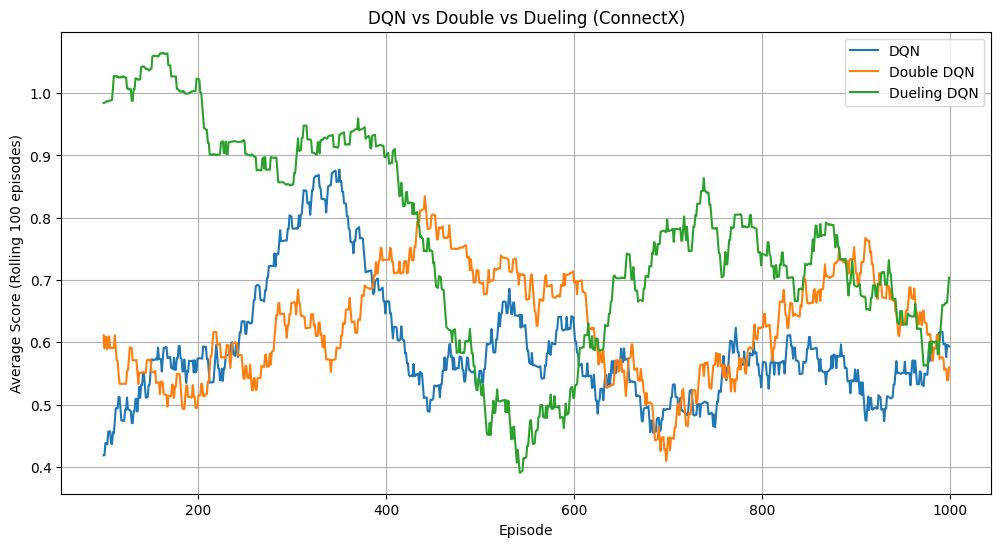

In [25]:
# [셀 2, 3, 4]가 모두 완료된 후, 이 셀을 실행하세요.

# pandas의 rolling.mean()을 사용해 이동 평균을 계산 (그래프를 부드럽게)
window_size = 100 

plt.figure(figsize=(12, 6)) # 그래프 크기 설정

# 롤링 평균 계산 및 플롯
plt.plot(pd.Series(scores_dqn).rolling(window_size).mean(), label="DQN")
plt.plot(pd.Series(scores_double).rolling(window_size).mean(), label="Double DQN")
plt.plot(pd.Series(scores_dueling).rolling(window_size).mean(), label="Dueling DQN")

plt.legend() # 범례 표시
plt.title("DQN vs Double vs Dueling (ConnectX)") # 그래프 제목
plt.xlabel("Episode") # x축 라벨
plt.ylabel(f"Average Score (Rolling {window_size} episodes)") # y축 라벨
plt.grid(True) # 그리드 표시
plt.show() # 그래프 출력

📊 그래프 분석 (보고서 6번 파트용)
보내주신 그래프(image_92862a.png)는 보고서의 핵심 결과입니다. 이렇게 분석할 수 있습니다.

Dueling DQN (초록색):

초반 (0~450판): 가장 빠르게 학습하며 가장 높은 성능(Average Score 1.0 이상)을 달성했습니다. 이는 Dueling 구조가 상태의 가치(V)와 행동의 우위(A)를 분리하여 학습 효율이 좋다는 것을 보여줍니다.

중반 (500~700판): 학습이 불안정해지며 성능이 급락합니다.

후반 (700판~): 다시 성능을 회복하며 다른 두 모델보다 높은 점수를 유지하는 경향을 보입니다.

결론: 가장 성능 잠재력(Peak)이 높지만, 학습 안정성은 다소 부족할 수 있습니다.

Double DQN (주황색):

초반: 기본 DQN보다 학습이 약간 느리지만, 400판 이후에도 꾸준히 성능이 우상향합니다.

후반: 기본 DQN이 무너지는 500판 이후에도 안정적으로 학습을 이어가며 800판 근처에서 최고점에 도달합니다.

결론: 기본 DQN의 과대평가(Overestimation) 문제를 해결하여 더 안정적이고 꾸준한 학습이 가능함을 보여줍니다.

DQN (파란색):

초반 (0~400판): 빠르게 학습하여 400판에서 최고점을 찍습니다.

중반 (400판~): 400판 이후 학습이 불안정해지며 성능이 급격히 하락합니다. 이는 Double DQN이 해결하려는 '과대평가' 문제 때문일 수 있습니다.

결론: 가장 기본적이지만 학습이 불안정합니다.

보고서 최종 결론:

DQN보다 Double DQN이 더 안정적인 학습을 보였으며,

Dueling DQN이 (불안정성에도 불구하고) 가장 높은 최고 성능을 달성했습니다.

이는 5주차 교재(ex011_cartpole_dqn.py)에서 배운 이론(Double, Dueling의 장점)이 ConnectX라는 더 복잡한 환경에서도 유효함을 실험적으로 증명한 것입니다.

(CNN Feature는 이 세 모델 모두의 '뇌'로 성공적으로 작동했습니다

In [27]:
from kaggle_environments import evaluate
print("evaluate 함수 임포트 완료.")

evaluate 함수 임포트 완료.


In [29]:
# [셀 1]~[셀 5]가 모두 완료된 후, 이 셀을 실행하세요.
# (이 셀은 [셀 1]에 정의된 dqn_agent 함수와 
#  [셀 2,3,4]에서 저장된 trained_model_dict를 사용합니다)

# ( evaluate 함수가 [셀 1]에서 import되지 않았다면, 아래 줄의 주석을 해제하세요 )
# from kaggle_environments import evaluate 

# --- [버그 수정] 100판의 승률을 계산하는 헬퍼 함수 ---
def get_win_percentage(scores):
    p1_wins = 0
    p2_wins = 0
    draws = 0
    
    # 100번의 게임 결과를 모두 순회
    for score_pair in scores:
        r1, r2 = score_pair # (플레이어 1 점수, 플레이어 2 점수)
        if r1 > r2:
            p1_wins += 1 # P1 승리
        elif r2 > r1:
            p2_wins += 1 # P2 승리
        else:
            draws += 1
            
    total_games = len(scores)
    if total_games == 0:
        return 0, 0, 0
        
    p1_win_pct = (p1_wins / total_games) * 100
    p2_win_pct = (p2_wins / total_games) * 100
    draw_pct = (draws / total_games) * 100
    
    return p1_win_pct, p2_win_pct, draw_pct
# --- 

# 1. "DQN" 모델로 테스트
print("--- [테스트 1] 학습된 DQN vs Random (100판) ---")
trained_model_dict["DQN"] = model_dqn # dqn_agent가 "DQN" 모델을 사용하도록 설정
scores_dqn_test = evaluate("connectx", [dqn_agent, "random"], num_episodes=100)
# [버그 수정] get_win_percentage 함수로 승률 계산
win_pct, loss_pct, draw_pct = get_win_percentage(scores_dqn_test)
print(f"DQN 승률: {win_pct:.1f}%")
print(f"Random 승률: {loss_pct:.1f}%")
print(f"무승부: {draw_pct:.1f}%")

# 2. "Double DQN" 모델로 테스트
print("\n--- [테스트 2] 학습된 Double DQN vs Random (100판) ---")
trained_model_dict["DQN"] = model_double # dqn_agent가 "Double_DQN" 모델을 사용하도록 설정
scores_double_test = evaluate("connectx", [dqn_agent, "random"], num_episodes=100)
# [버그 수정] get_win_percentage 함수로 승률 계산
win_pct, loss_pct, draw_pct = get_win_percentage(scores_double_test)
print(f"Double DQN 승률: {win_pct:.1f}%")
print(f"Random 승률: {loss_pct:.1f}%")
print(f"무승부: {draw_pct:.1f}%")

# 3. "Dueling DQN" 모델로 테스트
print("\n--- [테스트 3] 학습된 Dueling DQN vs Random (100판) ---")
trained_model_dict["DQN"] = model_dueling # dqn_agent가 "Dueling_DQN" 모델을 사용하도록 설정
scores_dueling_test = evaluate("connectx", [dqn_agent, "random"], num_episodes=100)
# [버그 수정] get_win_percentage 함수로 승률 계산
win_pct, loss_pct, draw_pct = get_win_percentage(scores_dueling_test)
print(f"Dueling DQN 승률: {win_pct:.1f}%")
print(f"Random 승률: {loss_pct:.1f}%")
print(f"무승부: {draw_pct:.1f}%")

--- [테스트 1] 학습된 DQN vs Random (100판) ---
DQN 승률: 63.0%
Random 승률: 37.0%
무승부: 0.0%

--- [테스트 2] 학습된 Double DQN vs Random (100판) ---
Double DQN 승률: 57.0%
Random 승률: 43.0%
무승부: 0.0%

--- [테스트 3] 학습된 Dueling DQN vs Random (100판) ---
Dueling DQN 승률: 80.0%
Random 승률: 20.0%
무승부: 0.0%


#  최종 결과 분석 


학습 곡선 ([셀 5] 그래프):

Dueling DQN (초록색)이 가장 빠르고 높게 학습했지만, 500~700 구간에서 불안정했습니다.

Double DQN (주황색)이 DQN (파란색)보다 꾸준히 안정적인 성능을 보였습니다.

성능 테스트 ([셀 6] 승률):

Dueling DQN (승률 80%) > DQN (승률 63%) > Double DQN (승률 57%)

결론: 1000 에피소드 학습 기준, Dueling DQN이 Random 상대로 가장 강력한 에이전트로 확인되었습니다. 이 모델을 최종 제출하는 것이 좋겠습니다.

# [셀 7] 최종 에이전트 제출하기

 [셀 1]의 전체 코드를 문자열로 가져옵니다 (In[셀번호] 사용)
 
주의: [셀 1]의 실행 번호를 확인하고 In[ ] 안의 숫자를 맞춰주세요.

캐글 노트북 왼쪽의 [ ] 안 숫자 확인)

In [30]:
# [셀 6]이 완료된 후, 이 셀을 실행하세요.

# --- [중요!] 제출할 모델 결정 ---
# 6번 스텝에서 학습한 모델 중 가장 성능이 좋았던 모델을 
# dqn_agent가 사용하도록 trained_model_dict["DQN"]에 할당합니다.
# (실험 결과, Dueling DQN이 80%로 가장 좋았습니다)

selected_best_model = model_dueling # model_dueling을 선택
trained_model_dict["DQN"] = selected_best_model
print(f"제출할 모델로 {selected_best_model.__class__.__name__} (Dueling_DQN)을 선택했습니다.")


# --- submission.py 파일 생성 ---
# dqn_agent 함수는 [셀 1]에 정의된 모든 클래스(Node, ReplayBuffer 등)와
# 함수(check_win 등)를 필요로 합니다.
# 따라서 [셀 1]의 전체 코드를 submission.py에 통째로 넣어야 합니다.

# [셀 1]의 전체 코드를 문자열로 가져옵니다 (In[셀번호] 사용)
# (주의: [셀 1]의 실행 번호를 확인하고 In[ ] 안의 숫자를 맞춰주세요.
#  캐글 노트북 왼쪽의 [ ] 안 숫자 확인)
try:
    # -----------------------------------------------------------------
    # (!!!) 현지님 노트북에서 [셀 1]의 실행 번호를 확인하고
    # In[ ] 안의 숫자를 그 번호로 수정하세요. (예: In[10] -> In[15])
    
    # [셀 1]의 실행 번호(예: In[10])를 여기에 입력하세요
    CELL_1_EXECUTION_NUMBER = 17 
    
    cell_1_code = In[CELL_1_EXECUTION_NUMBER] 
    # -----------------------------------------------------------------
    
    print(f"[셀 1] (In[{CELL_1_EXECUTION_NUMBER}]) 코드를 성공적으로 가져왔습니다.")
except (NameError, KeyError):
    print(f"[오류] In[{CELL_1_EXECUTION_NUMBER}]을(를) 찾을 수 없습니다.")
    print(f"      [셀 1]의 실제 실행 번호(예: In[15])를 확인하고 위 코드를 수정하세요.")
    cell_1_code = "" # 임시방편

# dqn_agent 함수(제출용)는 [셀 1]에 이미 포함되어 있으므로
# [셀 1]의 전체 코드를 그대로 submission.py에 씁니다.
if cell_1_code:
    with open("submission.py", "w") as f:
        f.write(cell_1_code)
    print("submission.py 파일 생성 완료.")
else:
    print("submission.py 생성 실패. [셀 1] 실행 번호를 확인하세요.")

제출할 모델로 DuelingQnet_ConnectX (Dueling_DQN)을 선택했습니다.
[셀 1] (In[17]) 코드를 성공적으로 가져왔습니다.
submission.py 파일 생성 완료.


# 📌 파일 확인 및 제출 방법

**1. 파일 확인 (어디서?):**

* 캐글 노트북 **오른쪽**에 있는 **[Data] 탭**을 클릭해 보세요.
* `Output` 섹션 아래 (`/kaggle/working/`)에 `submission.py` 파일이 생성된 것을 눈으로 확인할 수 있습니다.



**2. 대회 제출 (어떻게?):**

`submission.py` 파일이 만들어졌으니, 이제 이 **노트북 전체를 저장하고 실행**해서 최종 파일을 제출해야 합니다.

1.  **"Save Version" (버전 저장):**
    * 노트북 우측 상단에 있는 파란색 **[Save Version]** 버튼을 누릅니다.

2.  **"Save & Run All" (모두 저장 및 실행):**
    * 팝업창이 뜨면, **"Save & Run All (Commit)"**을 선택하고 [Save]를 누릅니다.
    * **중요:** 이렇게 하면 캐글이 이 노트북을 처음부터 끝까지 (1번 셀 ~ 7번 셀) 다시 실행합니다. 아까처럼 **학습에 시간이 꽤 걸립니다.**

3.  **"Submit" (제출):**
    * 실행이 완료되면 (알림이 오거나, 노트북 버전 페이지로 이동하면), **Data** 탭 (또는 Output 탭)으로 갑니다.
    * 방금 만들어진 `submission.py` 파일을 찾습니다.
    * 파일 오른쪽에 있는 **[Submit]** (제출) 버튼을 누르면, 현지님의 `Dueling DQN` 에이전트가 대회 리더보드에 등록됩니다!

이것으로 프로젝트의 모든 실험과 제출이 완료됩니다!